In [2]:
# ==============================
# Data Manipulation
# ==============================

import pandas as pd
import numpy as np

# ==============================
# Machine Learning Models
# ==============================

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ==============================
# Model Selection
# ==============================

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    KFold
)

# ==============================
# Evaluation Metrics
# ==============================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==============================
# Visualization
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Utilities
# ==============================

import joblib
import warnings

warnings.filterwarnings("ignore")

In [3]:
X_train = joblib.load('../Data/X_train_reg.pkl')
X_test = joblib.load('../Data/X_test_reg.pkl')

y_train = joblib.load('../Data/y_train_reg.pkl')
y_test = joblib.load('../Data/y_test_reg.pkl')

print(X_train.shape)
print(X_test.shape)

(38257, 66)
(7537, 66)


In [4]:
def evaluate_regression_model(model, X_train, y_train, X_test, y_test):
    
    # Train
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": model.__class__.__name__,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# baseline

In [5]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, y_pred_baseline))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_baseline)))
print("Baseline R2:", r2_score(y_test, y_pred_baseline))

Baseline MAE: 1728.0604967467755
Baseline RMSE: 1973.935366482234
Baseline R2: -7.085346103163914e-07


# Linear Regression

In [6]:
lr = LinearRegression()

lr_result = evaluate_regression_model(
    lr,
    X_train,
    y_train,
    X_test,
    y_test
)

print(lr_result)

{'Model': 'LinearRegression', 'MAE': 782.5342443159307, 'RMSE': np.float64(999.572814829968), 'R2': 0.7435732526336453}


# Decision Tree

In [7]:
dt = DecisionTreeRegressor(random_state=42)

dt_result = evaluate_regression_model(
    dt,
    X_train,
    y_train,
    X_test,
    y_test
)

print(dt_result)

{'Model': 'DecisionTreeRegressor', 'MAE': 366.5171819026138, 'RMSE': np.float64(654.1321746790767), 'R2': 0.8901840371772063}


# Random Forest

In [8]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_result = evaluate_regression_model(
    rf,
    X_train,
    y_train,
    X_test,
    y_test
)

print(rf_result)

{'Model': 'RandomForestRegressor', 'MAE': 287.6908425102826, 'RMSE': np.float64(506.77880768456595), 'R2': 0.9340869600529634}


# XGBoost

In [9]:
xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_result = evaluate_regression_model(
    xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

print(xgb_result)

{'Model': 'XGBRegressor', 'MAE': 280.05607911492433, 'RMSE': np.float64(480.67108329132236), 'R2': 0.9407033110554976}


In [10]:
results = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result,
    xgb_result
])

results

,Model,MAE,RMSE,R2
0,LinearRegression,782.534244,999.572815,0.743573
1,DecisionTreeRegressor,366.517182,654.132175,0.890184
2,RandomForestRegressor,287.690843,506.778808,0.934087
3,XGBRegressor,280.056079,480.671083,0.940703


In [11]:
y_pred_xgb = xgb.predict(X_test)

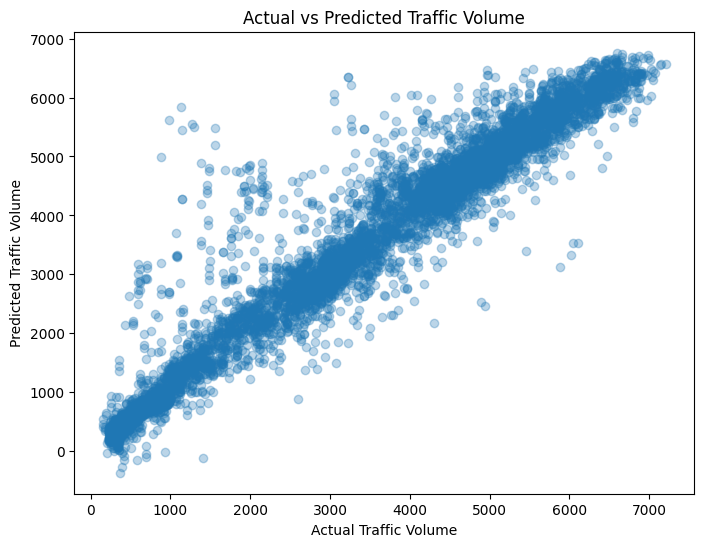

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.3)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume")

plt.show()

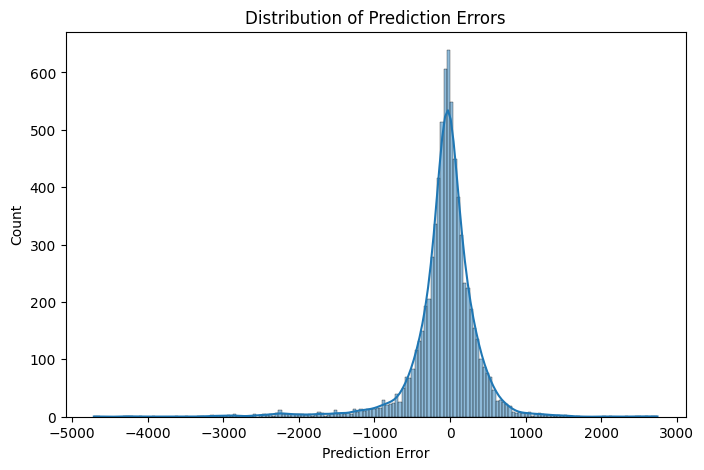

In [13]:
errors = y_test - y_pred_xgb

plt.figure(figsize=(8, 5))

sns.histplot(errors, kde=True)

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.show()

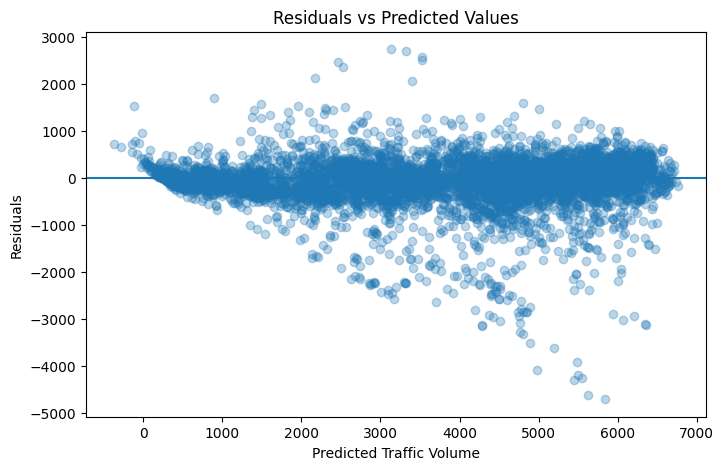

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_xgb, errors, alpha=0.3)

plt.axhline(0)

plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

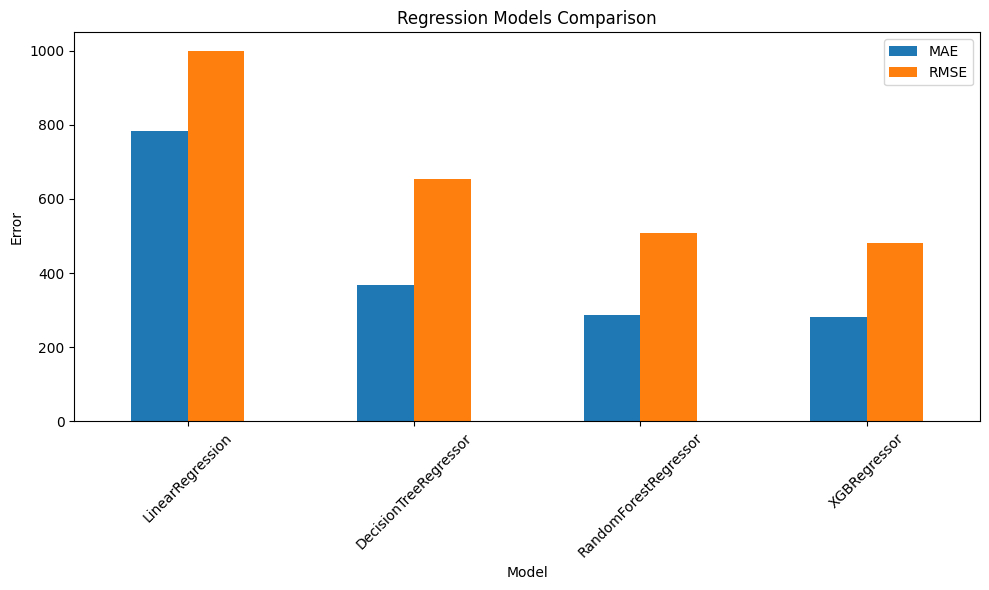

In [15]:
results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regression Models Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

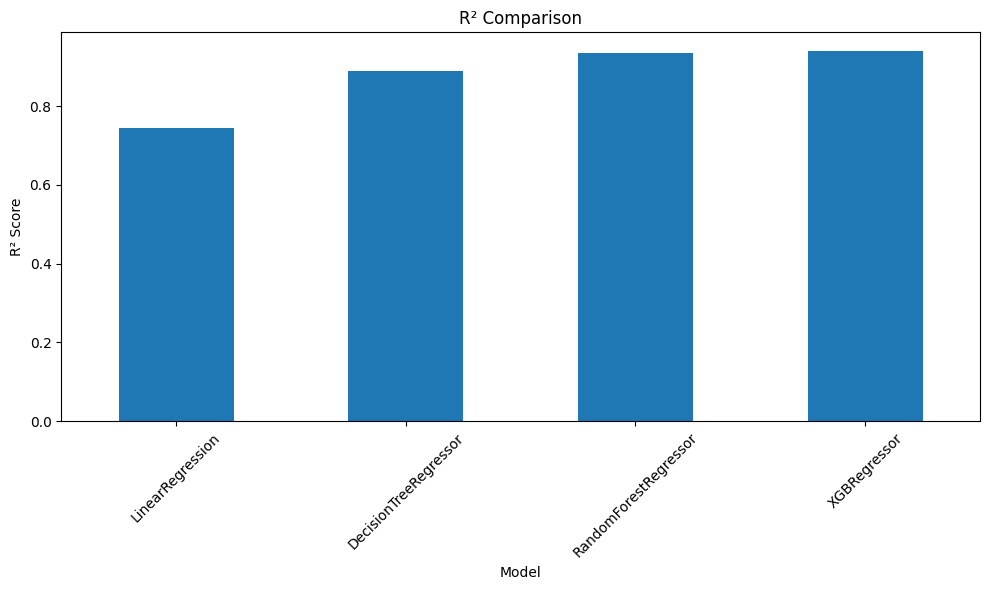

In [16]:
results.set_index("Model")["R2"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hyperparameter Search Space

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [18]:
xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [19]:
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

In [20]:
random_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_distributions,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [21]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [22]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [23]:
print("Best CV RMSE:")
print(-random_search.best_score_)

Best CV RMSE:
512.9092185842734


In [24]:
best_xgb = random_search.best_estimator_

In [37]:
best_xgb_reg = random_search.best_estimator_

In [38]:
joblib.dump(
    best_xgb_reg,
    '../Models/best_xgb_reg.pkl'
)

['../Data/best_xgb_reg.pkl']

In [25]:
y_pred_tuned = best_xgb.predict(X_test)

In [26]:
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned)
)

tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned XGBoost Results")
print("-" * 30)
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

Tuned XGBoost Results
------------------------------
MAE: 278.0649057069191
RMSE: 486.6102633834828
R²: 0.9392289163642618


In [27]:
regression_comparison = pd.DataFrame({
    'Model': [
        'XGBoost Before Tuning',
        'XGBoost After Tuning'
    ],
    
    'MAE': [
        280.06,
        tuned_mae
    ],
    
    'RMSE': [
        480.67,
        tuned_rmse
    ],
    
    'R²': [
        0.9407,
        tuned_r2
    ]
})

regression_comparison

,Model,MAE,RMSE,R²
0,XGBoost Before Tuning,280.060000,480.670000,0.940700
1,XGBoost After Tuning,278.064906,486.610263,0.939229


In [28]:
final_regression_model = xgb

In [29]:
final_regression_model.fit(
    X_train,
    y_train
)

y_pred_final_reg = final_regression_model.predict(X_test)

In [30]:
y_pred_final_reg = final_regression_model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_mae = mean_absolute_error(
    y_test,
    y_pred_final_reg
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_final_reg
    )
)

final_r2 = r2_score(
    y_test,
    y_pred_final_reg
)

print("Final Regression Model Results")
print("-" * 35)
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Regression Model Results
-----------------------------------
MAE : 280.05607911492433
RMSE: 480.67108329132236
R²  : 0.9407033110554976


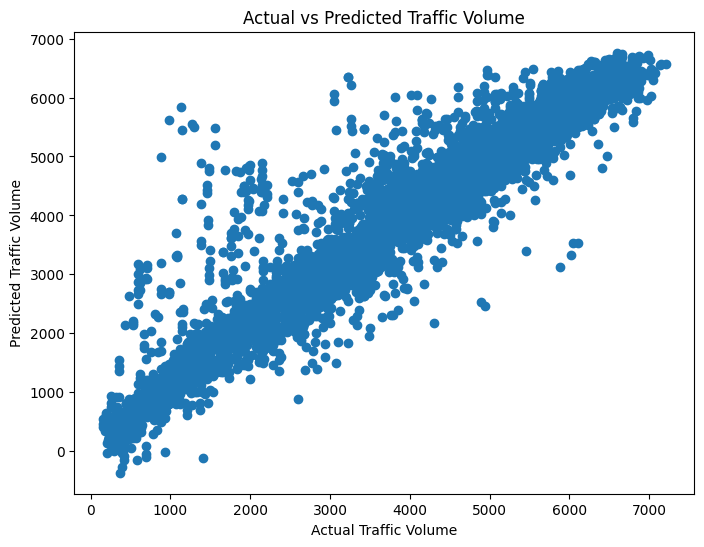

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_final_reg
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")

plt.title("Actual vs Predicted Traffic Volume")

plt.show()

In [33]:
residuals = y_test - y_pred_final_reg

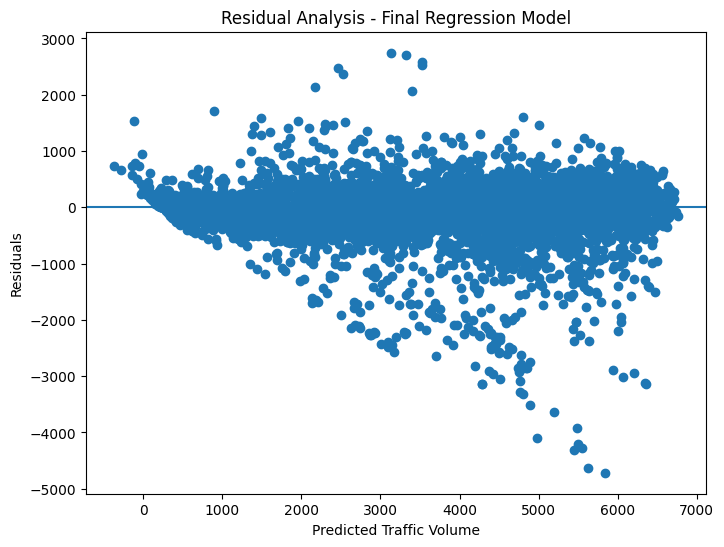

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_final_reg,
    residuals
)

plt.axhline(
    y=0
)

plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")

plt.title("Residual Analysis - Final Regression Model")

plt.show()

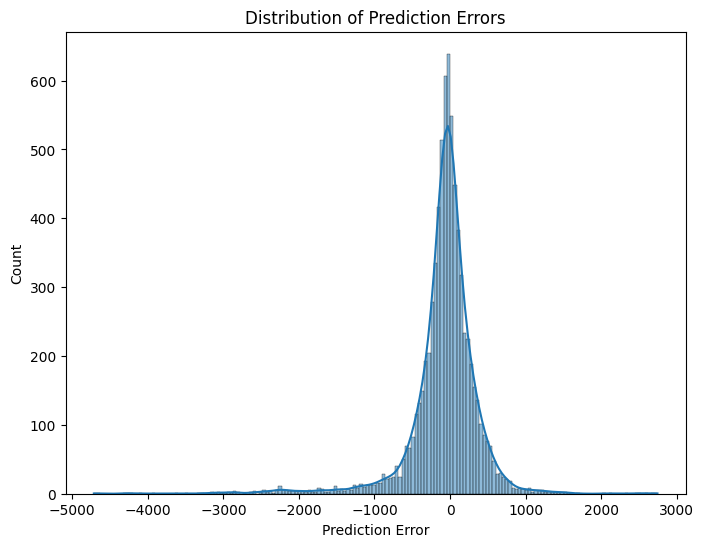

In [35]:
plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Prediction Error")

plt.title("Distribution of Prediction Errors")

plt.show()

In [36]:
final_regression_results = pd.DataFrame({
    'Model': [
        'Final XGBoost Regression'
    ],
    
    'MAE': [
        final_mae
    ],
    
    'RMSE': [
        final_rmse
    ],
    
    'R²': [
        final_r2
    ]
})

final_regression_results

,Model,MAE,RMSE,R²
0,Final XGBoost Regression,280.056079,480.671083,0.940703
